# Projet de Mathématiques Financières - M1 MBFA

**Auteurs :** Guillaume ANTOULIN, Ruben BENSOUSSAN  
**Groupe de TD :** 1  
**Sujet :** 5 

<p align="center">
  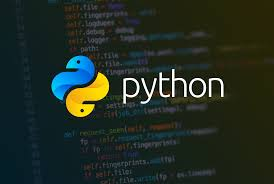
    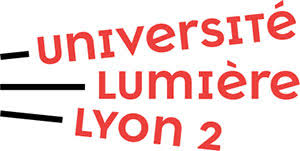
    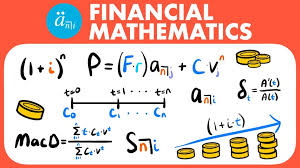
</p>



## Présentation du sujet
Ce projet a pour objectif de concevoir une calculatrice financière interactive codée en Python. Elle permet à l'utilisateur de réaliser des calculs complexes basés sur les concepts théoriques vus en cours (Chapitres 2 à 6). L'objectif est de faciliter la prise de décision financière via une interface utilisateur.

## Fonctionnalités du programme
Le programme est structuré en plusieurs modules accessibles via un menu principal :

1.  **Actualisation & Capitalisation (Chapitre 2)** : Calcul de la valeur actuelle nette (VAN) et future en intérêts simples, composés et continus.
2.  **Annuités (Chapitre 3)** : Calcul de la valeur acquise ou actuelle d'une suite de flux (constants, progression arithmétique ou géométrique).
3.  **Emprunts Indivis (Chapitre 4)** : Génération automatique du tableau d'amortissement sous forme de DataFrame `pandas` pour trois types d'emprunts :
    * Remboursement par annuités constantes.
    * Remboursement par amortissements constants.
    * Remboursement In Fine.
4.  **Obligations (Chapitre 5)** : Pricing d'obligations classiques et zéro-coupon.
5.  **Gestion de Portefeuille (Chapitre 6)** : Calcul de l'espérance et de la variance d'un portefeuille à 2 actifs et visualisation de la frontière efficiente avec `matplotlib`(Modèle Espérance-Variance).


<p align="center">
    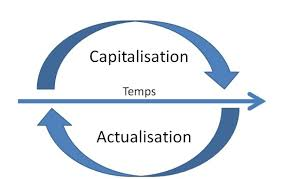
    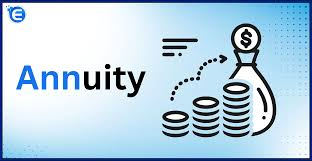
    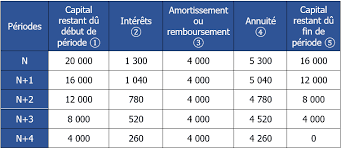
    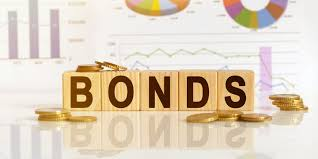
    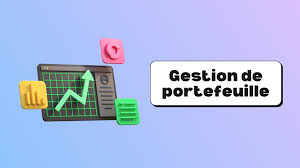
</p>



## Choix techniques
* **Modularité** : Chaque thème financier correspond à une fonction distincte.
* **Bibliothèques** : Utilisation de `numpy` (calcul vectoriel), `pandas` (tableaux structurés) et `matplotlib` (graphiques).
* **Robustesse** : Gestion des erreurs de saisie utilisateur via des blocs `try... except`.

## Limitations
* **Taux de rendement interne (TRI)** : Le programme ne calcule pas le TRI par itération (Newton-Raphson) pour ne pas complexifier le code outre mesure et sans utiliser d'éléments non vus en cours (`scipy`).
* **Gestion d'erreurs** : Bien que des protections existent (division par zéro), certaines entrées utilisateurs aberrantes (ex: texte au lieu de chiffre) pourraient nécessiter un redémarrage de la fonction.
* **Théorie de l'Utilité (Chap 6)** : Le module de portefeuille se base uniquement sur le modèle Espérance-Variance (Markowitz). Le modèle de l'Utilité Espérée (MTUE) n'est pas intégré car il dépend de fonctions d'utilité subjectives (propres à chaque investisseur) difficiles à modéliser dans une interface générique.
* **Gestion des dates** : Le programme raisonne en "nombre de périodes" ($n=1, 2, 3...$) et non en dates calendaires réelles (ex: 12/01/2024). Il ne prend pas en compte les conventions de comptage de jours (Exact/360, 30/360) ni les années bissextiles.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# MODULE 1 : ACTUALISATION ET CAPITALISATION (Chapitre 2)
# ==========================================

def calcul_valeur_future(C0, t, n, mode='compose'):
    """
    Calcule la valeur future (Cn) d'un capital initial selon différents modes de capitalisation.
    
    Cette fonction implémente les formules du Chapitre 2 pour :
    - Les intérêts simples [Chap 2, Section 2]
    - Les intérêts composés [Chap 2, Section 3]
    - La capitalisation en temps continu [Chap 2, Section 4]

    Args:
        C0 (float): Le capital initial investi à la date t=0.
        t (float): Le taux d'intérêt exprimé en décimal (ex: 0.05 pour 5%).
                   Pour le mode continu, correspond au taux instantané (delta).
        n (float): La durée du placement ou le nombre de périodes.
        mode (str, optional): Le mode de calcul. 
            - 'simple' : Intérêts calculés uniquement sur le capital initial.
            - 'compose' : Intérêts capitalisés périodiquement (par défaut).
            - 'continu' : Capitalisation instantanée exponentielle.

    Returns:
        float: La valeur future acquise (Cn) au bout de n périodes.
        None: Si le mode spécifié n'est pas reconnu.
    """
    if mode == 'simple':
        # Formule Chap 2: Cn = C0 * (1 + n*t)
        return C0 * (1 + n * t)
    elif mode == 'compose':
        # Formule Chap 2: Cn = C0 * (1 + t)**n
        return C0 * (1 + t)**n
    elif mode == 'continu':
        # Formule Chap 2: Cn = C0 * exp(delta * n) où t est le taux continu
        return C0 * np.exp(t * n)
    else:
        return None

def calcul_van(flux, taux):
    """
    Calcule la Valeur Actuelle Nette (VAN) d'une séquence de flux financiers.
    
    La VAN est la somme des flux de trésorerie actualisés au taux de marché.
    Elle permet d'évaluer la rentabilité d'un projet d'investissement [Chap 2, Section 6].

    Args:
        flux (list of float): Une liste contenant les flux de trésorerie.
            - L'élément à l'index 0 correspond au flux en t=0 (souvent l'investissement initial négatif).
            - L'élément à l'index k correspond au flux en t=k.
        taux (float): Le taux d'actualisation (coût du capital) exprimé en décimal.

    Returns:
        float: La Valeur Actuelle Nette du projet. Une VAN > 0 indique un projet créateur de valeur.
    """
    van = 0
    # Utilisation d'une boucle for avec enumerate pour avoir l'index (temps)
    for t, f in enumerate(flux):
        van += f / (1 + taux)**t
    return van

# ==========================================
# MODULE 2 : ANNUITÉS (Chapitre 3)
# ==========================================

def calcul_annuite(a, n, i, type_annuite='constante', q=0, r=0):
    """
    Calcule la Valeur Actuelle (V0) et la Valeur Acquise (Vn) d'une suite d'annuités.

    Cette fonction couvre les différents types d'annuités vus au Chapitre 3 :
    - Annuités constantes [Chap 3, Section 3]
    - Annuités en progression géométrique [Chap 3, Section 5]
    - Annuités en progression arithmétique [Chap 3, Section 4]

    Args:
        a (float): Le montant du premier versement (ou versement constant).
        n (int): Le nombre total de versements.
        i (float): Le taux d'intérêt périodique (en décimal).
        type_annuite (str, optional): Le type de progression des flux.
            Valeurs possibles : 'constante', 'geometrique', 'arithmetique'.
        q (float, optional): La raison de la suite géométrique (ex: 1.02 pour +2%/an).
            Requis uniquement si type_annuite='geometrique'.
        r (float, optional): La raison de la suite arithmétique (montant ajouté à chaque période).
            Requis uniquement si type_annuite='arithmetique'.

    Returns:
        tuple: Un couple (V0, Vn) contenant :
            - V0 (float) : La valeur actuelle de la suite de flux (en t=0).
            - Vn (float) : La valeur acquise de la suite de flux (en t=n).
    """
    v0 = 0
    vn = 0
    
    if type_annuite == 'constante':
        # Formule Chap 3 : V0 = a * [1 - (1+i)^-n] / i
        v0 = a * (1 - (1 + i)**-n) / i
        vn = v0 * (1 + i)**n
        
    elif type_annuite == 'geometrique':
        # Formule Chap 3 Section 5
        if q == 1 + i:
            v0 = n * a / (1 + i)
        else:
            v0 = a * (1 - (q / (1 + i))**n) / (1 + i - q)
        vn = v0 * (1 + i)**n

    elif type_annuite == 'arithmetique':
        # Formule Chap 3 Section 4
        # On utilise une boucle pour la robustesse et éviter les erreurs de formule complexe
        flux = []
        for k in range(1, n + 1):
            flux_k = a + (k - 1) * r
            flux.append(flux_k)
        
        # Actualisation manuelle
        for k, f in enumerate(flux):
            v0 += f / (1 + i)**(k + 1)
        vn = v0 * (1 + i)**n
        
    return v0, vn

# ==========================================
# MODULE 3 : EMPRUNTS (Chapitre 4)
# ==========================================

def tableau_amortissement(V0, n, i, mode='annuites_constantes'):
    """
    Génère le tableau d'amortissement complet d'un emprunt indivis.

    Le tableau détaille pour chaque période la répartition entre intérêts et capital remboursé
    selon les modalités définies au Chapitre 4.

    Args:
        V0 (float): Le montant initial du capital emprunté.
        n (int): La durée de l'emprunt (nombre d'échéances).
        i (float): Le taux d'intérêt périodique de l'emprunt (en décimal).
        mode (str, optional): La modalité de remboursement.
            - 'annuites_constantes' : L'emprunteur paie la même somme à chaque période [Chap 4, Section 4].
            - 'amortissements_constants' : L'emprunteur rembourse la même part de capital [Chap 4, Section 5].
            - 'in_fine' : Le capital est remboursé en totalité à la dernière échéance [Chap 4, Section 6].

    Returns:
        pandas.DataFrame: Un DataFrame contenant les colonnes :
            - 'Période' : Numéro de l'échéance.
            - 'Capital Début' : Capital restant dû avant paiement.
            - 'Intérêts' : Montant des intérêts de la période.
            - 'Amortissement' : Part de capital remboursé.
            - 'Annuité' : Montant total payé (Intérêts + Amortissement).
            - 'Capital Fin' : Capital restant dû après paiement.
    """
    periodes = np.arange(1, n + 1)
    interets = []
    amortissements = []
    annuites = []
    capital_restant = [V0] # On initialise avec V0
    
    # Calculs selon le mode choisi
    if mode == 'annuites_constantes':
        # Calcul de l'annuité constante (Chap 4, Section 4)
        a = V0 * i / (1 - (1 + i)**-n)
        
        crd = V0
        for p in periodes:
            int_p = crd * i
            am_p = a - int_p
            crd = crd - am_p
            
            interets.append(int_p)
            amortissements.append(am_p)
            annuites.append(a)
            capital_restant.append(crd)
            
    elif mode == 'amortissements_constants':
        # Amortissement constant (Chap 4, Section 5)
        am_const = V0 / n
        
        crd = V0
        for p in periodes:
            int_p = crd * i
            am_p = am_const
            ann_p = int_p + am_p
            crd = crd - am_p
            
            interets.append(int_p)
            amortissements.append(am_p)
            annuites.append(ann_p)
            capital_restant.append(crd)
            
    elif mode == 'in_fine':
        # In Fine (Chap 4, Section 6)
        crd = V0
        for p in periodes:
            int_p = V0 * i
            if p == n:
                am_p = V0
            else:
                am_p = 0
            
            ann_p = int_p + am_p
            crd = crd - am_p
            
            interets.append(int_p)
            amortissements.append(am_p)
            annuites.append(ann_p)
            capital_restant.append(crd)

    # Création du Dictionnaire pour Pandas
    data = {
        "Période": periodes,
        "Capital Début": capital_restant[:-1],
        "Intérêts": interets,
        "Amortissement": amortissements,
        "Annuité": annuites,
        "Capital Fin": capital_restant[1:]
    }
    
    # Création et formatage du DataFrame
    df = pd.DataFrame(data)
    # Arrondir pour l'affichage
    df = df.round(2)
    return df

# ==========================================
# MODULE 4 : OBLIGATIONS (Chapitre 5)
# ==========================================

def prix_obligation(nominal, taux_coupon, taux_marche, maturite, type_obl='classique'):
    """
    Calcule le prix théorique (valeur actuelle) d'une obligation.

    Le prix correspond à la somme actualisée des flux futurs (coupons + remboursement)
    selon le taux de rendement actuariel (Yield to Maturity).

    Args:
        nominal (float): La valeur nominale (ou faciale) de l'obligation (V).
        taux_coupon (float): Le taux facial qui détermine le montant du coupon (j).
        taux_marche (float): Le taux de rendement actuariel ou taux d'évaluation (i ou y).
        maturite (int): La durée de vie restante de l'obligation en années.
        type_obl (str, optional): Le type d'obligation.
            - 'classique' : Verse des coupons périodiques et rembourse le nominal à la fin [Chap 5, Section 3].
            - 'zero_coupon' : Ne verse aucun coupon, seul le nominal est payé à l'échéance [Chap 5, Section 4].

    Returns:
        float: Le prix de marché (P) de l'obligation.
    """
    if type_obl == 'zero_coupon':
        # Chap 5, Section 4 : P = R / (1+i)^n (en supposant R=V)
        prix = nominal / (1 + taux_marche)**maturite
    else:
        # Chap 5, Section 3 : Obligation classique
        coupon = nominal * taux_coupon
        # Actualisation des coupons
        prix = 0
        for t in range(1, maturite + 1):
            prix += coupon / (1 + taux_marche)**t
        # Actualisation du remboursement (au pair)
        prix += nominal / (1 + taux_marche)**maturite
        
    return prix

# ==========================================
# MODULE 5 : PORTEFEUILLE (Chapitre 6)
# ==========================================

def analyse_portefeuille(mu1, sig1, mu2, sig2, rho):
    """
    Simule un portefeuille composé de deux actifs risqués, trace la frontière efficiente,
    identifie le portefeuille de variance minimale (MVP) et enregistre le graphique.

    Args:
        mu1 (float): Rendement espéré Actif 1.
        sig1 (float): Risque (écart-type) Actif 1.
        mu2 (float): Rendement espéré Actif 2.
        sig2 (float): Risque (écart-type) Actif 2.
        rho (float): Corrélation (-1 à 1).

    Returns:
        None: Affiche le graphique et l'enregistre localement.
    """
    # 1. Génération de la frontière (Graphique)
    w1 = np.linspace(0, 1, 100)
    w2 = 1 - w1
    cov = rho * sig1 * sig2
    
    rp_exp = w1 * mu1 + w2 * mu2
    rp_var = (w1**2 * sig1**2) + (w2**2 * sig2**2) + (2 * w1 * w2 * cov)
    rp_sig = np.sqrt(rp_var)

    # 2. Calcul du Portefeuille de Variance Minimale (Formule exacte du Cours)
    numerateur = sig2**2 - rho * sig1 * sig2
    denominateur = sig1**2 + sig2**2 - 2 * rho * sig1 * sig2
    
    # Protection contre la division par zéro
    if denominateur == 0:
        w1_min = 0.5 
    else:
        w1_min = numerateur / denominateur

    # On contraint le poids entre 0 et 1
    w1_min = max(0, min(1, w1_min))
    w2_min = 1 - w1_min
    
    # Calcul des caractéristiques de ce portefeuille optimal
    min_exp = w1_min * mu1 + w2_min * mu2
    min_var = (w1_min**2 * sig1**2) + (w2_min**2 * sig2**2) + (2 * w1_min * w2_min * cov)
    min_sig = np.sqrt(min_var)

    # --- Affichages Textuels ---
    print(f"\n--- Portefeuille de Variance Minimale (MVP) ---")
    print(f"Poids Actif 1 : {w1_min*100:.2f} %")
    print(f"Poids Actif 2 : {w2_min*100:.2f} %")
    print(f"Rendement Espéré : {min_exp:.4f}")
    print(f"Risque Minimum (Sigma) : {min_sig:.4f}")

    # --- Graphique ---
    plt.figure(figsize=(10, 6))
    plt.plot(rp_sig, rp_exp, label='Frontière efficiente', color='blue')
    
    # Ajout du point MVP sur le graphique
    plt.scatter([min_sig], [min_exp], color='orange', marker='*', s=200, label='Min Variance (MVP)', zorder=5)
    
    # Points des actifs individuels
    plt.scatter([sig1], [mu1], color='red', marker='o', s=100, label='Actif 1')
    plt.scatter([sig2], [mu2], color='green', marker='o', s=100, label='Actif 2')
    
    plt.title(f"Frontière Efficiente & Portefeuille Min Variance (rho={rho})")
    plt.xlabel("Risque (Écart-type)")
    plt.ylabel("Rendement Espéré")
    plt.grid(True, linestyle='--')
    plt.legend()
    
    # --- ENREGISTREMENT AUTOMATIQUE ---
    graphique = "frontiere_efficiente.png"
    plt.savefig(graphique)
    print(f"\n[INFO] Le graphique a été enregistré automatiquement sous '{graphique}'")
    
    plt.show()

# ==========================================
# INTERFACE UTILISATEUR (MENU PRINCIPAL)
# ==========================================

def menu_principal():
    """Fonction qui gère l'interaction avec l'utilisateur via la boucle while."""
    continuer = True
    
    while continuer:
        print("\n" + "="*40)
        print("   CALCULATRICE MATHÉMATIQUES FINANCIÈRES")
        print("="*40)
        print("1. Actualisation & Capitalisation (Chap 2)")
        print("2. Annuités (Chap 3)")
        print("3. Tableau d'amortissement Emprunt (Chap 4)")
        print("4. Valorisation Obligation (Chap 5)")
        print("5. Gestion Portefeuille 2 Actifs (Chap 6)")
        print("6. Quitter")
        print("-" * 40)
        
        choix = input("Votre choix (1-6) : ")
        
        if choix == '1':
            print("\n--- Actualisation & Capitalisation (Chap 2) ---")
            sous_choix = input("1. Valeur Future (Cn)\n2. Valeur Actuelle Nette (VAN)\nVotre choix : ")
            
            if sous_choix == '1':
                try:
                    c = float(input("Capital initial (C0) : "))
                    t = float(input("Taux (ex: 0.05) : "))
                    n = float(input("Durée : "))
                    m = input("Mode (simple/compose/continu) : ")
                    res = calcul_valeur_future(c, t, n, m)
                    if res is not None:
                        print(f"La valeur future est de : {res:.2f}")
                    else:
                        print("Erreur : Mode inconnu.")
                except ValueError:
                    print("Erreur : Veuillez entrer des nombres valides.")
            
            elif sous_choix == '2':
                try:
                    flux_str = input("Entrez les flux séparés par des virgules (ex: -100,50,60) : ")
                    flux = [float(x) for x in flux_str.split(',')]
                    taux = float(input("Taux d'actualisation (ex: 0.10) : "))
                    van = calcul_van(flux, taux)
                    print(f"La valeur actuelle nette (VAN) est de : {van:.2f}")
                except ValueError:
                    print("Erreur de saisie des flux.")

        elif choix == '2':
            print("\n--- Calcul Annuités ---")
            try:
                a = float(input("Montant 1er flux : "))
                n = int(input("Nombre de périodes : "))
                i = float(input("Taux périodique (ex: 0.04) : "))
                type_a = input("Type (constante/geometrique/arithmetique) : ")
                
                q_val, r_val = 0, 0
                if type_a == 'geometrique':
                    q_val = float(input("Raison q (ex: 1.02) : "))
                elif type_a == 'arithmetique':
                    r_val = float(input("Raison r (montant) : "))
                
                v0, vn = calcul_annuite(a, n, i, type_a, q_val, r_val)
                print(f"La valeur actuelle (V0) est de : {v0:.2f}")
                print(f"La valeur acquise (Vn) est de : {vn:.2f}")
            except ValueError:
                print("Erreur de saisie.")

        elif choix == '3':
            print("\n--- Tableau d'amortissement ---")
            try:
                k = float(input("Capital emprunté : "))
                dur = int(input("Durée (nombre d'échéances) : "))
                tx = float(input("Taux périodique (ex: 0.05) : "))
                
                print("Modes : 1=Annuites Constantes, 2=Amortissements Constants, 3=In Fine")
                m_choice = input("Choix mode (1/2/3) : ")
                mode_map = {'1': 'annuites_constantes', '2': 'amortissements_constants', '3': 'in_fine'}
                
                if m_choice in mode_map:
                    df = tableau_amortissement(k, dur, tx, mode_map[m_choice])
                    print("\nRésultat :")
                    print(df.to_string(index=False)) # Affichage propre sans l'index pandas
                
                    # --- AJOUT COMMANDE EXPORT AUTOMATIQUE ---
                    nom_fichier = "tableau_amortissement.xlsx"
                    df.to_excel(nom_fichier, index=False)
                    print(f"\n[INFO] Le tableau a été enregistré automatiquement sous '{nom_fichier}'")
                    
                else:
                    print("Mode invalide.")
            except ValueError:
                print("Erreur : Entrée numérique requise.")

        elif choix == '4':
            print("\n--- Pricing Obligation ---")
            try:
                nom = float(input("Valeur Nominale : "))
                coup = float(input("Taux Coupon (ex: 0.06) : "))
                mkt = float(input("Taux Marché (YTM) (ex: 0.05) : "))
                mat = int(input("Maturité (années) : "))
                typ = input("Type (classique/zero_coupon) : ")
                
                px = prix_obligation(nom, coup, mkt, mat, typ)
                print(f"Le prix de l'obligation est de : {px:.2f}")
                
                if px > nom:
                    print("Cotation : Au-dessus du pair")
                elif px < nom:
                    print("Cotation : En-dessous du pair")
                else:
                    print("Cotation : Au pair")
            except ValueError:
                print("Erreur de saisie.")

        elif choix == '5':
            print("\n--- Frontière Efficiente (2 actifs) ---")
            try:
                m1 = float(input("Rendement espéré Actif 1 (ex: 0.08) : "))
                s1 = float(input("Écart-type Actif 1 (ex: 0.15) : "))
                m2 = float(input("Rendement espéré Actif 2 (ex: 0.04) : "))
                s2 = float(input("Écart-type Actif 2 (ex: 0.05) : "))
                rho = float(input("Corrélation (-1 à 1) : "))
                
                if -1 <= rho <= 1:
                    analyse_portefeuille(m1, s1, m2, s2, rho)
                else:
                    print("La corrélation doit être entre -1 et 1.")
            except ValueError:
                print("Erreur : Chiffres attendus.")

        elif choix == '6':
            print("Au revoir !")
            continuer = False
            
        else:
            print("Choix non reconnu, veuillez réessayer.")

# ==========================================
# LANCEMENT DU PROGRAMME
# ==========================================
if __name__ == "__main__":
    # Cette condition permet d'exécuter le menu seulement si le fichier est lancé directement
    menu_principal()


   CALCULATRICE MATHÉMATIQUES FINANCIÈRES
1. Actualisation & Capitalisation (Chap 2)
2. Annuités (Chap 3)
3. Tableau d'amortissement Emprunt (Chap 4)
4. Valorisation Obligation (Chap 5)
5. Gestion Portefeuille 2 Actifs (Chap 6)
6. Quitter
----------------------------------------


Votre choix (1-6) :  1



--- Actualisation & Capitalisation (Chap 2) ---


1. Valeur Future (Cn)
2. Valeur Actuelle Nette (VAN)
Votre choix :  1
Capital initial (C0) :  98,19


Erreur : Veuillez entrer des nombres valides.

   CALCULATRICE MATHÉMATIQUES FINANCIÈRES
1. Actualisation & Capitalisation (Chap 2)
2. Annuités (Chap 3)
3. Tableau d'amortissement Emprunt (Chap 4)
4. Valorisation Obligation (Chap 5)
5. Gestion Portefeuille 2 Actifs (Chap 6)
6. Quitter
----------------------------------------


...


--- Tableau d'amortissement ---


Capital emprunté :  1000
Durée (nombre d'échéances) :  10
Taux périodique (ex: 0.05) :  0.05


Modes : 1=Annuites Constantes, 2=Amortissements Constants, 3=In Fine


Choix mode (1/2/3) :  1



Résultat :
 Période  Capital Début  Intérêts  Amortissement  Annuité  Capital Fin
       1        1000.00     50.00          79.50    129.5       920.50
       2         920.50     46.02          83.48    129.5       837.02
       3         837.02     41.85          87.65    129.5       749.36
       4         749.36     37.47          92.04    129.5       657.33
       5         657.33     32.87          96.64    129.5       560.69
       6         560.69     28.03         101.47    129.5       459.22
       7         459.22     22.96         106.54    129.5       352.67
       8         352.67     17.63         111.87    129.5       240.80
       9         240.80     12.04         117.46    129.5       123.34
      10         123.34      6.17         123.34    129.5         0.00

[INFO] Le tableau a été enregistré automatiquement sous 'tableau_amortissement.xlsx'

   CALCULATRICE MATHÉMATIQUES FINANCIÈRES
1. Actualisation & Capitalisation (Chap 2)
2. Annuités (Chap 3)
3. Tableau d'a